In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()


In [7]:
n = 10000
ketqua = rng.integers(0, 2, n)  # 0 - sấp, 1 - ngửa
tan_suat = np.cumsum(ketqua) / np.arange(1, n + 1)

for i in [4, 10, 100, 1000, 5000, 10000]:
    print(f'n = {i}: số lần ngửa: {ketqua[:i].sum()}, tần suất: {tan_suat[i-1]}')

n = 4: số lần ngửa: 3, tần suất: 0.75
n = 10: số lần ngửa: 8, tần suất: 0.8
n = 100: số lần ngửa: 48, tần suất: 0.48
n = 1000: số lần ngửa: 476, tần suất: 0.476
n = 5000: số lần ngửa: 2447, tần suất: 0.4894
n = 10000: số lần ngửa: 4934, tần suất: 0.4934


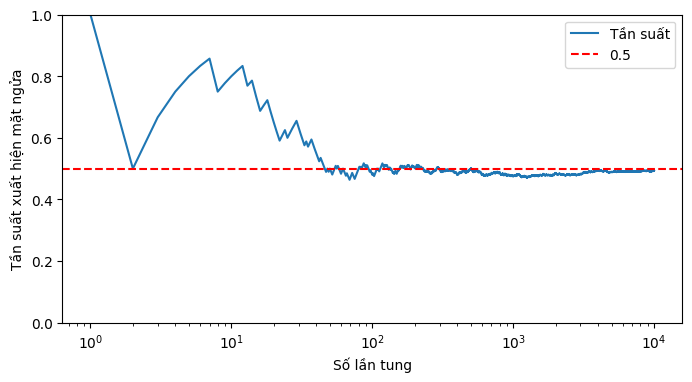

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, n+1), tan_suat, label='Tần suất')
plt.axhline(0.5, color='r', linestyle='--', label='0.5')
plt.xscale("log")
plt.ylim(0, 1)
plt.xlabel('Số lần tung')
plt.ylabel('Tần suất xuất hiện mặt ngửa')
plt.legend()

In [10]:
def bayes(prior, tpr, fpr):
    # prior: xác suất tiên nghiệm (vd: xác suất mắc bệnh trong dân số)
    # tpr: true positive rate P(+|bệnh)
    # fpr: false positive rate P(+|o bệnh)
    p_duong_tinh = tpr * prior + fpr * (1 - prior)
    return tpr * prior / p_duong_tinh

In [11]:
prior = 0.01
tpr = 0.99
fpr = 0.05
print(f'P(bệnh | +) = {bayes(prior, tpr, fpr)}')

P(bệnh | +) = 0.16666666666666669


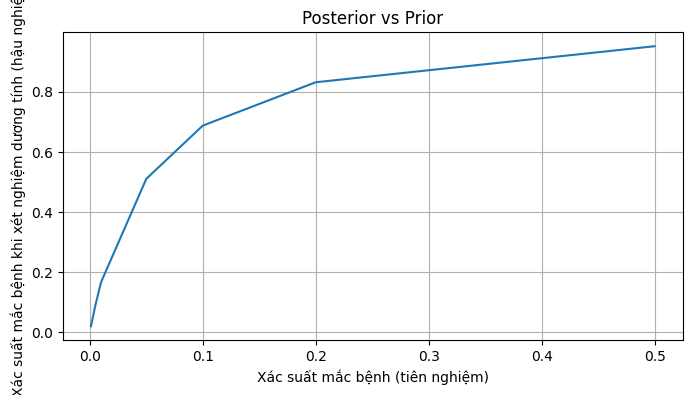

In [12]:
priors = np.array([0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5])
posts = np.array([bayes(pr, 0.99, 0.05) for pr in priors])

plt.figure(figsize=(8, 4))
plt.plot(priors, posts)
plt.xlabel('Xác suất mắc bệnh (tiên nghiệm)')
plt.ylabel('Xác suất mắc bệnh khi xét nghiệm dương tính (hậu nghiệm)')
plt.title('Posterior vs Prior')
plt.grid()
plt.show()